# GLM regression models using sociodemographic variables (X) and mortality (y) at different moments of the COVID-19 pandemic.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, pearsonr
from scipy.stats import skew, kurtosis
import numpy as np
from scipy.stats import poisson
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
import pickle
import seaborn as sns

from thesis import util
from thesis.correlation_sociodemographic_covid.util import tunning_negative_binomial_model, save_model, \
    summarize_results, outlier_analysis

## Loading data

In [2]:
df_variables = pd.read_csv('data/df_without_collinearity_standardized.csv', index_col=0)

In [3]:
df_variables = df_variables.drop(columns=['percentage_population_age_range_60_more', 'percentage_male_population'])

In [4]:
df_y = pd.read_csv('data/df_mortality.csv', index_col=0)

In [5]:
df_municipalities = pd.read_csv('data/df_base_without_missing_points.csv', index_col=0)

In [6]:
df_latitude_longitude = df_municipalities[['latitude', 'longitude']].copy()

In [7]:
df_cluster_probabilities = pd.read_csv('data/df_standardized_pca_2spherical_5_probability.csv', index_col=0)
df_cluster_probabilities.columns = ['Semi-urbanized', 'Urbanized', 'Rural with high human development', 'Urbanized with informal settlements', 'Rural with low human development']

In [8]:
df_cluster_labels = pd.read_csv('data/df_labeled_cluster.csv', index_col=0)[['cluster_label']].copy()
custom_order = pd.CategoricalDtype(
    categories=[
        'Urbanized',
        'Urbanized with informal settlements',
        'Semi-urbanized',
        'Rural with high human development',
        'Rural with low human development'
    ],
    ordered=True
)
df_cluster_labels['cluster_label'] = df_cluster_labels['cluster_label'].astype(custom_order)
df_cluster_labels = df_cluster_labels.sort_values('cluster_label')

In [9]:
df_regions = df_municipalities[['region']].copy()
custom_order = pd.CategoricalDtype(
    categories=['Sudeste', 'Norte', 'Nordeste', 'Sul', 'Centro-Oeste'], ordered=True
)
df_regions['region'] = df_regions['region'].astype(custom_order)
df_regions = df_regions.sort_values('region')

In [10]:
df_political = pd.read_csv('data/df_political_without_missing_points.csv', index_col=0)[['percentual_votes_for_bolsonaro']]

## Analyzing mortality rate distribution

In [11]:
for column in ['expected_deaths_1s_2020', 'expected_deaths_2020', 'expected_deaths_2021', 'expected_deaths_2022', 'expected_deaths_entire']:
    y = df_y[column].values
    y_mean = y.mean()    
    y_var = y.var()
    y_dispersion = y_var/y_mean
    print(column,':', 'mean = ', round(y_mean,2), 'var = ', round(y_var,2), 'dispersion = ', round(y_dispersion,2))
    
    y_bootstrap = np.random.choice(y, size=100000)
    
    x_values = np.arange(0, int(y_bootstrap.max()))
    pmf_values = poisson.pmf(x_values, mu=y_mean)
    
    # Plot the Poisson distribution
    # plt.figure(figsize=(8, 6))
    # plt.hist(y_bootstrap, bins=int(len(set(y_bootstrap.astype(int)))/1), density=True, color='red', alpha=0.7, label='empirical distribution')
    # plt.bar(x_values, pmf_values, color='blue', alpha=0.9, label=f'λ = {y_mean}')
    # plt.title('Poisson Distribution Analysis')
    # plt.xlabel('Death rate')
    # plt.ylabel('Probability')
    # plt.legend()
    # plt.show()

expected_deaths_1s_2020 : mean =  33373.61 var =  3606295535.08 dispersion =  108058.3
expected_deaths_2020 : mean =  132683.88 var =  11193851553.13 dispersion =  84364.82
expected_deaths_2021 : mean =  342614.74 var =  35447211414.9 dispersion =  103460.85
expected_deaths_2022 : mean =  58296.02 var =  2490752187.58 dispersion =  42725.94
expected_deaths_entire : mean =  533594.66 var =  64980456665.45 dispersion =  121778.69


In [12]:
df_y.columns

Index(['code_municipality_6', 'code_municipality_7', 'population', 'date',
       'region', 'deaths', 'new_deaths',
       'deaths_accumulated_first_semester_2020',
       'delta_first_death_2020-06-30', 'deaths_accumulated_2020',
       'delta_first_death_2020-12-31', 'deaths_accumulated_2021',
       'delta_first_death_2021-12-31', 'delta_first_death_2022-12-31',
       'delta_first_death_general_period',
       'death_rate_accumulated_first_semester_2020',
       'death_rate_accumulated_2020', 'death_rate_accumulated_2021',
       'Death rate (accumulated period)', 'Death rate (2022)',
       'Death rate (2021)', 'Death rate (2020)', 'Death rate (1/2020)',
       'deaths_2022', 'deaths_2021', 'death_accumulated_2020_04',
       'death_accumulated_2020_04_rate', 'death_accumulated_2020_06',
       'death_accumulated_2020_06_rate', 'death_accumulated_2020_08',
       'death_accumulated_2020_08_rate', 'death_accumulated_2020_10',
       'death_accumulated_2020_10_rate', 'death_accumula

In [13]:
for column in ['SMR_1s_2020', 'SMR_2020']:
    print('\nColumn:', column)
    print(df_y[column].describe().round(2))


Column: SMR_1s_2020
count    5560.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: SMR_1s_2020, dtype: float64

Column: SMR_2020
count    5560.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: SMR_2020, dtype: float64


In [14]:
def check_normality(data, label):
    print('\n***Data: ', label)
    
    statistic, p_value = shapiro(data)
    print("Shapiro-Wilk Test Statistic:", statistic)
    print("p-value:", p_value)    
    if p_value > 0.05:
        print("Sample looks Gaussian (fail to reject H0)")
    else:
        print("Sample does not look Gaussian (reject H0)")
    # Compute skewness
    skewness = skew(data)
    # Compute kurtosis
    kurt = kurtosis(data)
    # Print the results
    print("Skewness:", skewness)
    print("Kurtosis:", kurt) 
    
    stats.probplot(data, dist="norm", plot=plt)
    plt.title('Normal Q-Q plot')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel(label)
    plt.grid(True)
    plt.show()    

In [15]:
def plot_results_basic(model, y, x):        
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, y, color='blue', label='Predicted vs Actual', edgecolors='blue', facecolors='none')
    plt.plot(y, y, color='red', label='Perfect Fit')
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Predicted vs Actual Values')
    plt.legend()
    plt.grid(True)
    plt.show()

    resid_pearson = model.resid_pearson    

    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, resid_pearson, color='blue', label='Predicted vs Pearson Residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(resid_pearson, model.fittedvalues, frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Predicted Values')
    plt.ylabel('resid_pearson')
    plt.title('Predicted vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()    

    check_normality(resid_pearson, 'resid_pearson')
    check_normality(y, 'y')

In [16]:
def plot_results(model, y, x):        
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, y, color='blue', label='Predicted vs Actual', edgecolors='blue', facecolors='none')
    plt.plot(y, y, color='red', label='Perfect Fit')
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Predicted vs Actual Values')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    population = df_y.loc[y.index]['population']
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues/population*100000, y/population*100000, color='blue', label='Predicted vs Actual (Death rates)', edgecolors='blue', facecolors='none')
    plt.plot(y/population*100000, y/population*100000, color='red', label='Perfect Fit')
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Predicted vs Actual (Death rates)')
    plt.legend()
    plt.grid(True)
    plt.show()    
    
    resid_response = model.resid_response
    resid_pearson = model.resid_pearson
    quantile_residuals = resid_response / np.sqrt(model.fittedvalues)
    
    standardized_pearson_residuals = resid_pearson / np.sqrt(model.fittedvalues)
    standardized_quantile_residuals = quantile_residuals / quantile_residuals.std()
    
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, resid_pearson, color='blue', label='Predicted vs Pearson Residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(resid_pearson, model.fittedvalues, frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Predicted Values')
    plt.ylabel('resid_pearson')
    plt.title('Predicted vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()    
    
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, standardized_pearson_residuals, color='blue', label='Predicted vs Pearson Residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(standardized_pearson_residuals, model.fittedvalues, frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Predicted Values')
    plt.ylabel('standardized_pearson_residuals')
    plt.title('Predicted vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()    
    
    plt.figure(figsize=(10, 6))
    plt.scatter(model.fittedvalues, standardized_quantile_residuals, color='blue', label='Predicted vs Pearson Residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(standardized_quantile_residuals, model.fittedvalues, frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Predicted Values')
    plt.ylabel('standardized_quantile_residuals')
    plt.title('Predicted vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()    
    
    check_normality(resid_response, 'resid_response')
    check_normality(resid_pearson, 'resid_pearson')
    check_normality(standardized_pearson_residuals, 'standardized_pearson_residuals')
    check_normality(quantile_residuals, 'quantile_residuals')
    check_normality(standardized_quantile_residuals, 'standardized_quantile_residuals')

    df_municipalities_temp = df_municipalities.loc[y.index]

    plt.figure(figsize=(10, 6))
    plt.scatter(df_municipalities_temp['longitude'], quantile_residuals, color='blue', label='Longitude vs residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(quantile_residuals, df_municipalities_temp['longitude'], frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Longitude')
    plt.ylabel('Residuals')
    plt.title('Longitude vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(df_municipalities_temp['latitude'], quantile_residuals, color='blue', label='Latitude vs residuals', edgecolors='blue', facecolors='none')
    lowess_smooth = lowess(quantile_residuals, df_municipalities_temp['latitude'], frac=0.2)
    plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
    plt.xlabel('Latitude')
    plt.ylabel('Residuals')
    plt.title('Latitude vs Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    for i in range(len(x.columns[1:])):
        plt.figure(figsize=(10, 6))
        plt.scatter(x[x.columns[1:][i]], quantile_residuals, color='blue', edgecolors='blue', facecolors='none')
        lowess_smooth = lowess(quantile_residuals, x[x.columns[1:][i]], frac=0.2)
        plt.plot(lowess_smooth[:, 0], lowess_smooth[:, 1], color='red', label='LOWESS Smooth Curve')
        plt.xlabel(x.columns[1:][i])
        plt.ylabel('Quantile Residuals')        
        plt.grid(True)
        plt.show()    

In [17]:
def collinearity_analysis(df_x):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = df_x.columns
    vif_data['VIF'] = [variance_inflation_factor(df_x.values, i) for i in range(df_x.shape[1])]
    return vif_data

In [18]:
def plot_pearson(df):
    palette = util.get_default_colors_heatmap()
    # Assuming df_without_collinearity_standardized is your DataFrame
    attributes = df.columns[:]
    n = len(attributes)
    yticks = [f"{i + 1} - {attr}" for i, attr in enumerate(attributes)]
    xticks = list(range(1, n + 1))

    # Select the desired attributes
    df_selected_attributes = df[attributes]

    # Calculate the Pearson correlation matrix
    correlation = df_selected_attributes.corr()

    # Initialize a matrix for p-values
    pvalue = np.zeros((n, n))

    # Compute p-values
    for i in range(n):
        for j in range(n):
            if i != j:
                _, pvalue[i, j] = pearsonr(df_selected_attributes.iloc[:, i], df_selected_attributes.iloc[:, j])
            else:
                pvalue[i, j] = np.nan  # NaN for diagonal

    # Round p-values to two decimal places
    pvalue = np.round(pvalue, 2)

    # Create a mask to hide the upper triangle
    mask = np.zeros_like(correlation, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    # Set plot dimensions
    largura = 70
    altura = 50

    # Convert dimensions from centimeters to inches
    def centimeter_to_inch(cm):
        return cm / 2.54

    # Set seaborn style
    sns.set(font_scale=1.1)
    sns.set_style("ticks")

    # Plot the correlation heatmap with annotations for correlation values
    f, ax = plt.subplots(figsize=(centimeter_to_inch(largura), centimeter_to_inch(altura)))
    ax = sns.heatmap(correlation, vmin=-1, vmax=1, center=0, square=False, mask=mask, cmap=palette,
                     yticklabels=yticks, xticklabels=xticks, annot=correlation, fmt=".2f",
                     cbar_kws={"orientation": "horizontal"}, cbar=True)
    plt.xticks(rotation=0)
    plt.show()

In [19]:
from thesis.correlation_sociodemographic_covid.util import zero_inflated_negative_binomial


def run_model(x, y, model_name, period, list_offset_extra=None, list_offset_extra_2=None, weights=None, is_offset_default=True, x_infl=None):
    if is_offset_default:
        list_population =  df_y.loc[df_y.index.isin(y.index), 'population']
        list_offset_default = np.log(list_population)
        if weights is not None:
            list_offset_default = pd.concat([list_offset_default, list_offset_default, list_offset_default], ignore_index=True)
    else:
        list_offset_default = list_offset_extra
        list_offset_extra = list_offset_extra_2
        list_offset_extra_2 = None

    model_name_period = model_name + '_' + period
    print('\n===>',model_name_period)
    print(collinearity_analysis(x))
    plot_pearson(x)
    x = sm.add_constant(x)

    # x.to_csv('data/models/'+model_name_period+'_x.csv', index=False)
    # y.to_csv('data/models/'+model_name_period+'_y.csv', index=False)
    # if list_offset_extra is not None:
    #     list_offset_default.to_csv('data/models/'+model_name_period+'_offset_default.csv', index=False)
    # if list_offset_extra_2 is not None:
    #     list_offset_extra_2.to_csv('data/models/'+model_name_period+'_offset_extra_2.csv', index=False)
    # if weights is not None:
    #     weights.to_csv('data/models/'+model_name_period+'_weights.csv', index=False)

    if x_infl is None:
        TREAT_ZERO_INFLATION = 0
        x = x.loc[y>TREAT_ZERO_INFLATION]
        if list_offset_default is not None:
            list_offset_default = list_offset_default.loc[y>TREAT_ZERO_INFLATION]
        if list_offset_extra is not None:
            list_offset_extra = list_offset_extra.loc[y>TREAT_ZERO_INFLATION]
        if list_offset_extra_2 is not None:
            list_offset_extra_2 = list_offset_extra_2.loc[y>TREAT_ZERO_INFLATION]
        if weights is not None:
            weights = weights.loc[y>TREAT_ZERO_INFLATION]
        y = y.loc[y>TREAT_ZERO_INFLATION]

        model = tunning_negative_binomial_model(x, y, list_offset_default, list_offset_extra, list_offset_extra_2, weights)
    else:
        model = zero_inflated_negative_binomial(x, y, list_offset_default, list_offset_extra, list_offset_extra_2, x_infl)

    save_model(model, model_name_period)
    summarize_results(model)
    plot_results_basic(model, y, x)
    outlier_analysis(model)
    return model

In [20]:
df_regions['region'].unique()

['Sudeste', 'Norte', 'Nordeste', 'Sul', 'Centro-Oeste']
Categories (5, object): ['Sudeste' < 'Norte' < 'Nordeste' < 'Sul' < 'Centro-Oeste']

## Statistical analysis
Model 0: regions without any control.<br/>
Model 1: regions controlled by temporal factor.<br/>
Model 2: clusters without any control.<br/>
Model 3: clusters controlled by temporal factor.<br/>
Model 4: latitude and longitude without any control.<br/>
Model 5: latitude, longitude, and clusters without any control. <br/>
Model 6: cluster probabilities without any control. <br/>
Model 7: latitude, longitude, and cluster probabilities without any control. <br/>
Model 8: latitude, longitude, and cluster probabilities controlled by temporal factor. <br/>
Model 9: cluster probabilities controlled by temporal factor. <br/>
Model 10: sociodemographic variables and political preference controlled by temporal factor. <br/>
Model 11: sociodemographic variables and political preference without any control. <br/>


In [21]:
deaths_2020 = df_y['deaths_accumulated_2020'].sum()
deaths_2021 = df_y['deaths_2021'].sum()
deaths_2022 = df_y['deaths_2022'].sum()

weight_2020 = deaths_2021 / deaths_2020
weight_2021 = deaths_2021 / deaths_2021
weight_2022 = deaths_2021 / deaths_2022

In [22]:
print(weight_2020)

1.9957305994106627


In [23]:
print(weight_2022)

6.491066644212073


In [24]:
df_y.columns

Index(['code_municipality_6', 'code_municipality_7', 'population', 'date',
       'region', 'deaths', 'new_deaths',
       'deaths_accumulated_first_semester_2020',
       'delta_first_death_2020-06-30', 'deaths_accumulated_2020',
       'delta_first_death_2020-12-31', 'deaths_accumulated_2021',
       'delta_first_death_2021-12-31', 'delta_first_death_2022-12-31',
       'delta_first_death_general_period',
       'death_rate_accumulated_first_semester_2020',
       'death_rate_accumulated_2020', 'death_rate_accumulated_2021',
       'Death rate (accumulated period)', 'Death rate (2022)',
       'Death rate (2021)', 'Death rate (2020)', 'Death rate (1/2020)',
       'deaths_2022', 'deaths_2021', 'death_accumulated_2020_04',
       'death_accumulated_2020_04_rate', 'death_accumulated_2020_06',
       'death_accumulated_2020_06_rate', 'death_accumulated_2020_08',
       'death_accumulated_2020_08_rate', 'death_accumulated_2020_10',
       'death_accumulated_2020_10_rate', 'death_accumula


*** Period:  2020_1


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Death mean:  33373.61 variance:  3606944266.06 dispersion:  108077.74


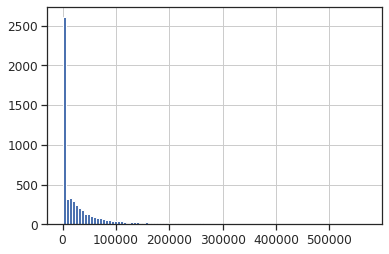

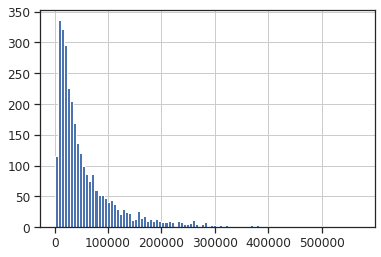


===> model_11_2020_1
                                              Feature       VIF
0                         percentage_urban_population  3.560787
1                    percentage_indigenous_population  1.130823
2           density_median_effectively_domiciled_area  1.975299
3                                                gini  1.646860
4   percentage_estimated_households_in_informal_se...  1.294677
5         demographic_density_in_informal_settlements  1.453317
6   percentage_hospitalizations_diseases_inadequat...  1.148422
7                    percentage_self_employed_workers  1.646229
8                                   unemployment_rate  1.666865
9                         percentage_workers_commerce  2.045059
10                        percentage_workers_services  2.771049
11                        percentage_workers_industry  2.096042
12              expected_years_of_schooling_at_age_18  1.437048
13                     percentage_votes_for_bolsonaro  1.972270


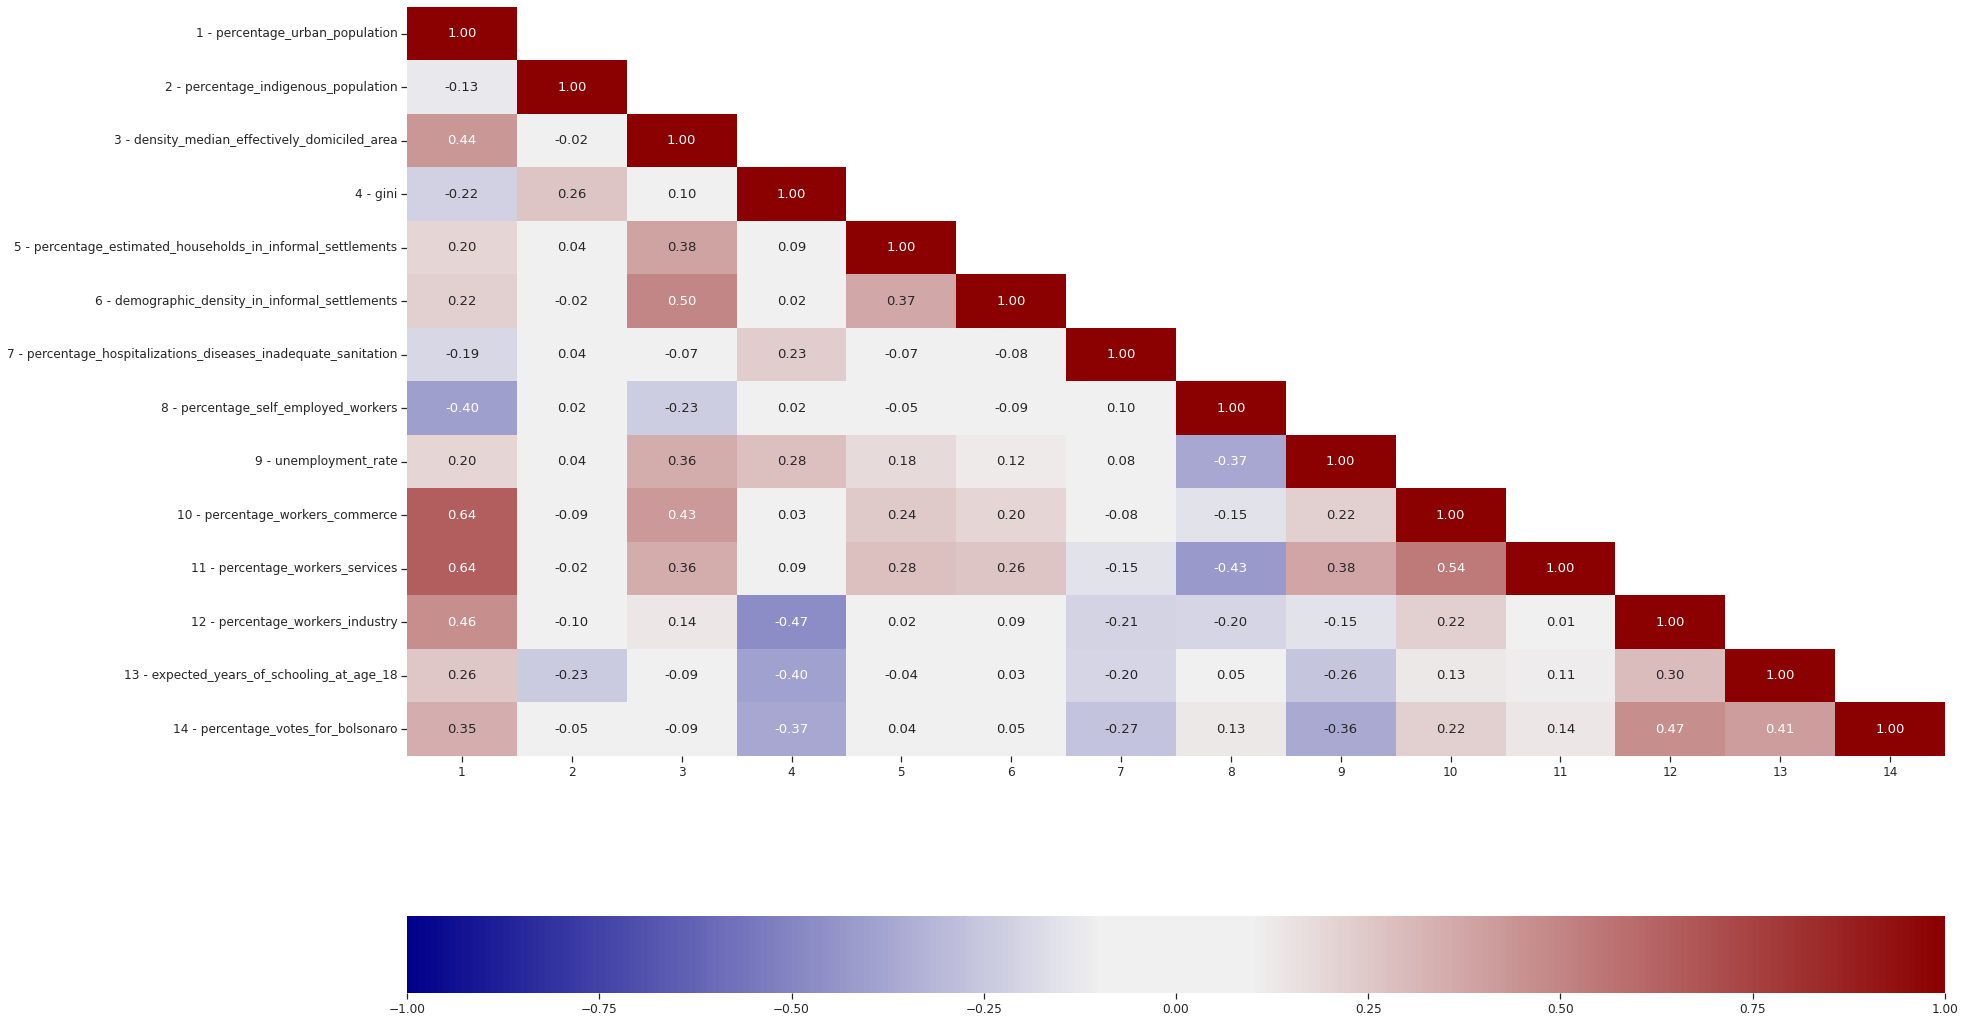

Selected alpha: 0.6900000000000001
                    Generalized Linear Model Regression Results                    
Dep. Variable:     expected_deaths_1s_2020   No. Observations:                 3045
Model:                                 GLM   Df Residuals:                     3030
Model Family:             NegativeBinomial   Df Model:                           14
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -36078.
Date:                     Fri, 20 Jun 2025   Deviance:                       3373.7
Time:                             17:03:26   Pearson chi2:                 4.28e+03
No. Iterations:                         11   Pseudo R-squ. (CS):             0.3161
Covariance Type:                 nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975

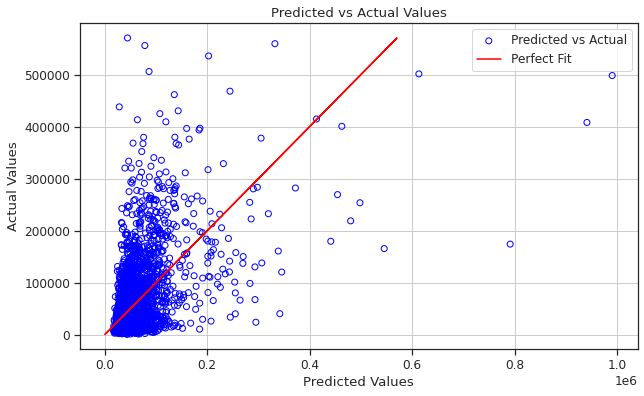

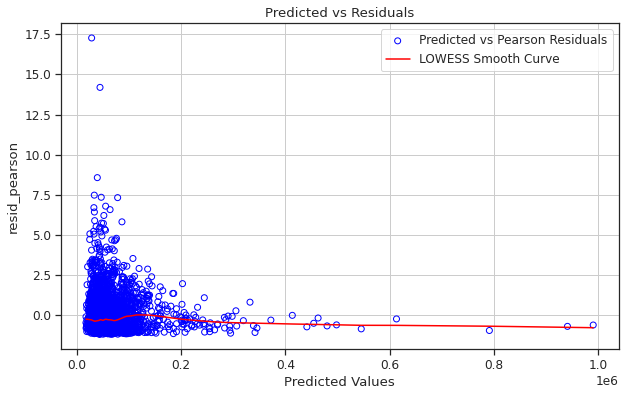


***Data:  resid_pearson
Shapiro-Wilk Test Statistic: 0.733748733997345
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 3.5022860459970317
Kurtosis: 27.15134678055538


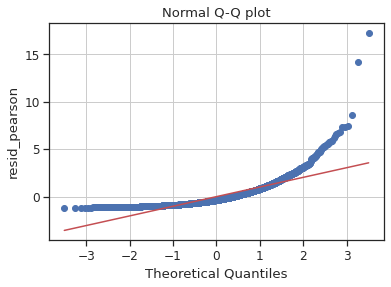


***Data:  y
Shapiro-Wilk Test Statistic: 0.7146698236465454
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 2.646048030450619
Kurtosis: 9.393250624440483


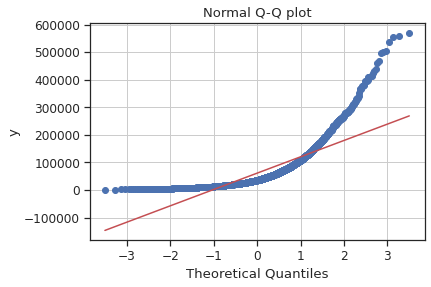

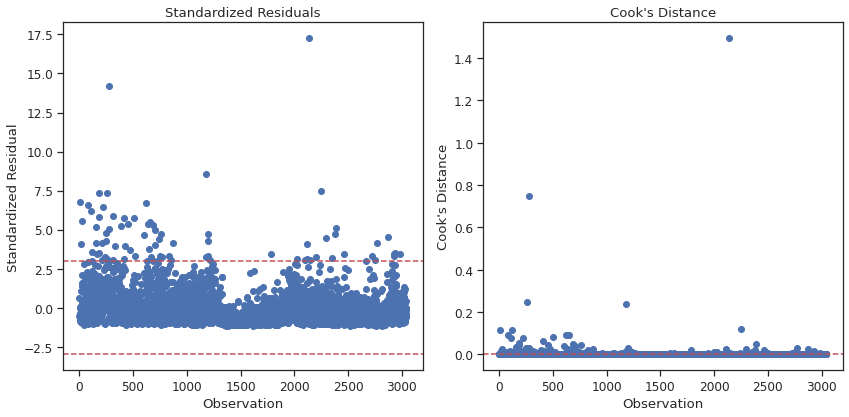

Quantity outliers (Standardized Residuals > 3): 79
Quantity influential Points (Cook's Distance > 4/n): 284

*** Period:  2020
Death mean:  132683.88 variance:  11195865197.95 dispersion:  84379.99


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


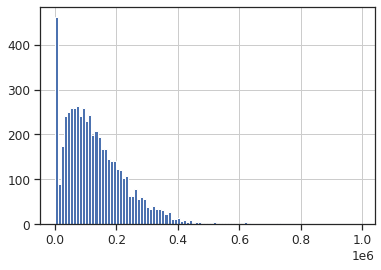

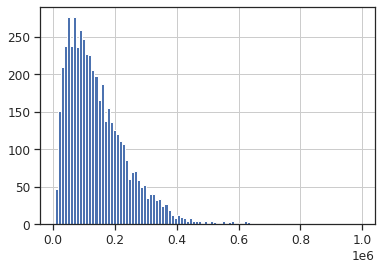


===> model_11_2020
                                              Feature       VIF
0                         percentage_urban_population  3.560787
1                    percentage_indigenous_population  1.130823
2           density_median_effectively_domiciled_area  1.975299
3                                                gini  1.646860
4   percentage_estimated_households_in_informal_se...  1.294677
5         demographic_density_in_informal_settlements  1.453317
6   percentage_hospitalizations_diseases_inadequat...  1.148422
7                    percentage_self_employed_workers  1.646229
8                                   unemployment_rate  1.666865
9                         percentage_workers_commerce  2.045059
10                        percentage_workers_services  2.771049
11                        percentage_workers_industry  2.096042
12              expected_years_of_schooling_at_age_18  1.437048
13                     percentage_votes_for_bolsonaro  1.972270


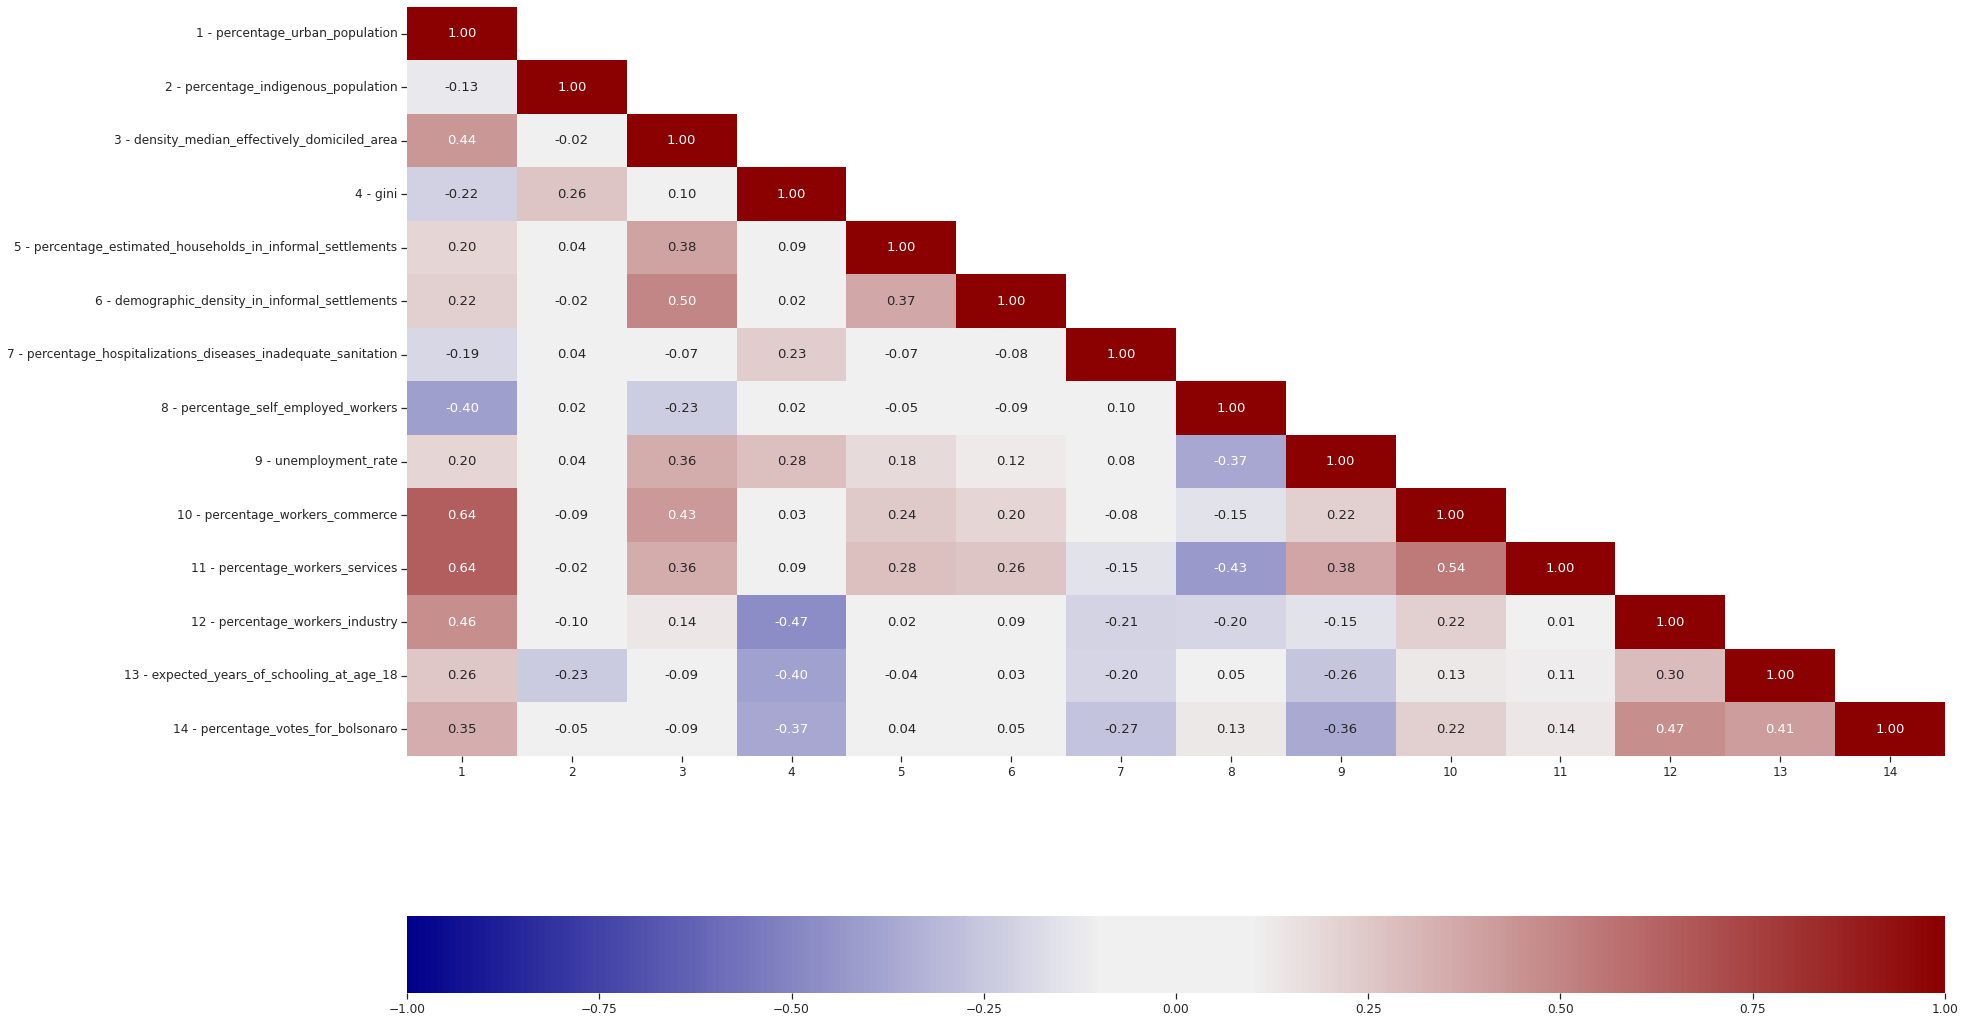

Selected alpha: 0.39
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2020   No. Observations:                 5110
Model:                              GLM   Df Residuals:                     5095
Model Family:          NegativeBinomial   Df Model:                           14
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -64557.
Date:                  Fri, 20 Jun 2025   Deviance:                       5382.3
Time:                          17:03:54   Pearson chi2:                 5.31e+03
No. Iterations:                       7   Pseudo R-squ. (CS):             0.2196
Covariance Type:              nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

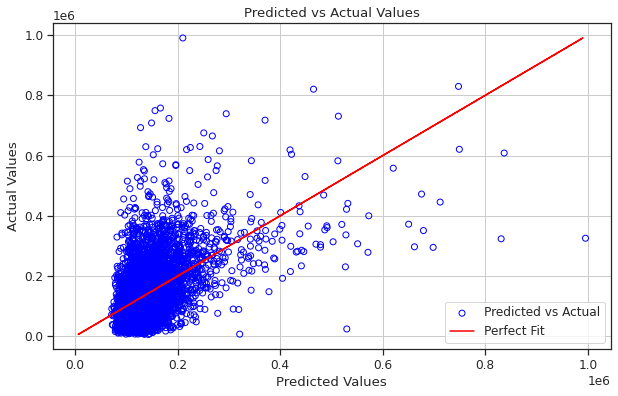

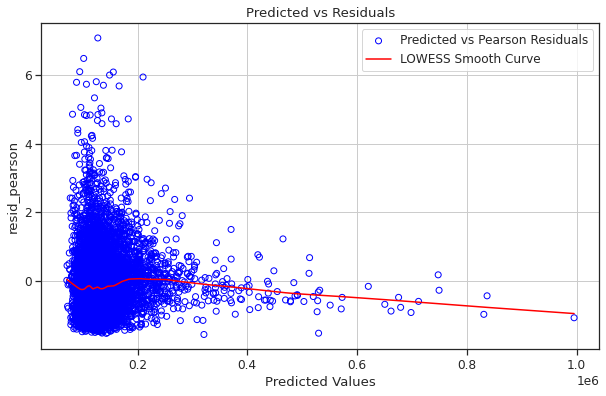


***Data:  resid_pearson
Shapiro-Wilk Test Statistic: 0.8982174396514893
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 1.5458007021147773
Kurtosis: 4.354823732092704


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


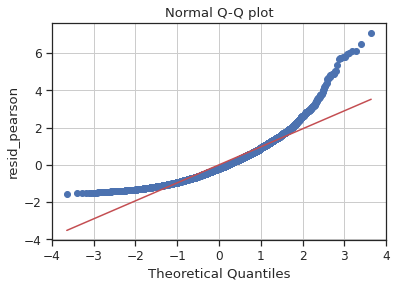


***Data:  y
Shapiro-Wilk Test Statistic: 0.8811630606651306
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 1.6533985240811355
Kurtosis: 4.896001750598013


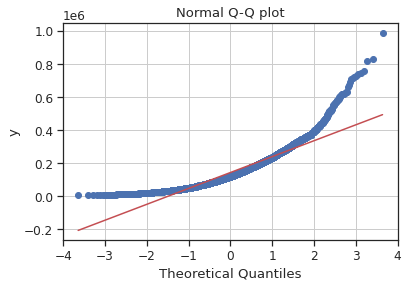

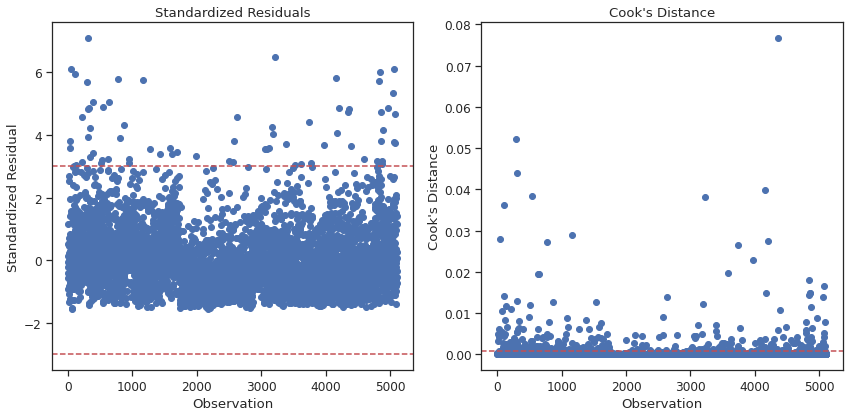

Quantity outliers (Standardized Residuals > 3): 72
Quantity influential Points (Cook's Distance > 4/n): 379

*** Period:  2021
Death mean:  342614.74 variance:  35453587959.49 dispersion:  103479.46


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


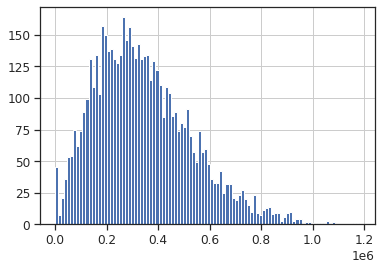

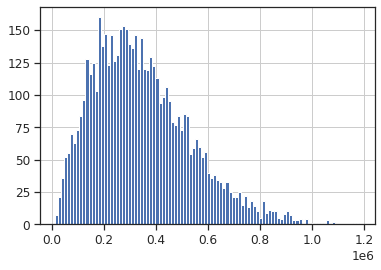


===> model_11_2021
                                              Feature       VIF
0                         percentage_urban_population  3.560787
1                    percentage_indigenous_population  1.130823
2           density_median_effectively_domiciled_area  1.975299
3                                                gini  1.646860
4   percentage_estimated_households_in_informal_se...  1.294677
5         demographic_density_in_informal_settlements  1.453317
6   percentage_hospitalizations_diseases_inadequat...  1.148422
7                    percentage_self_employed_workers  1.646229
8                                   unemployment_rate  1.666865
9                         percentage_workers_commerce  2.045059
10                        percentage_workers_services  2.771049
11                        percentage_workers_industry  2.096042
12              expected_years_of_schooling_at_age_18  1.437048
13                     percentage_votes_for_bolsonaro  1.972270


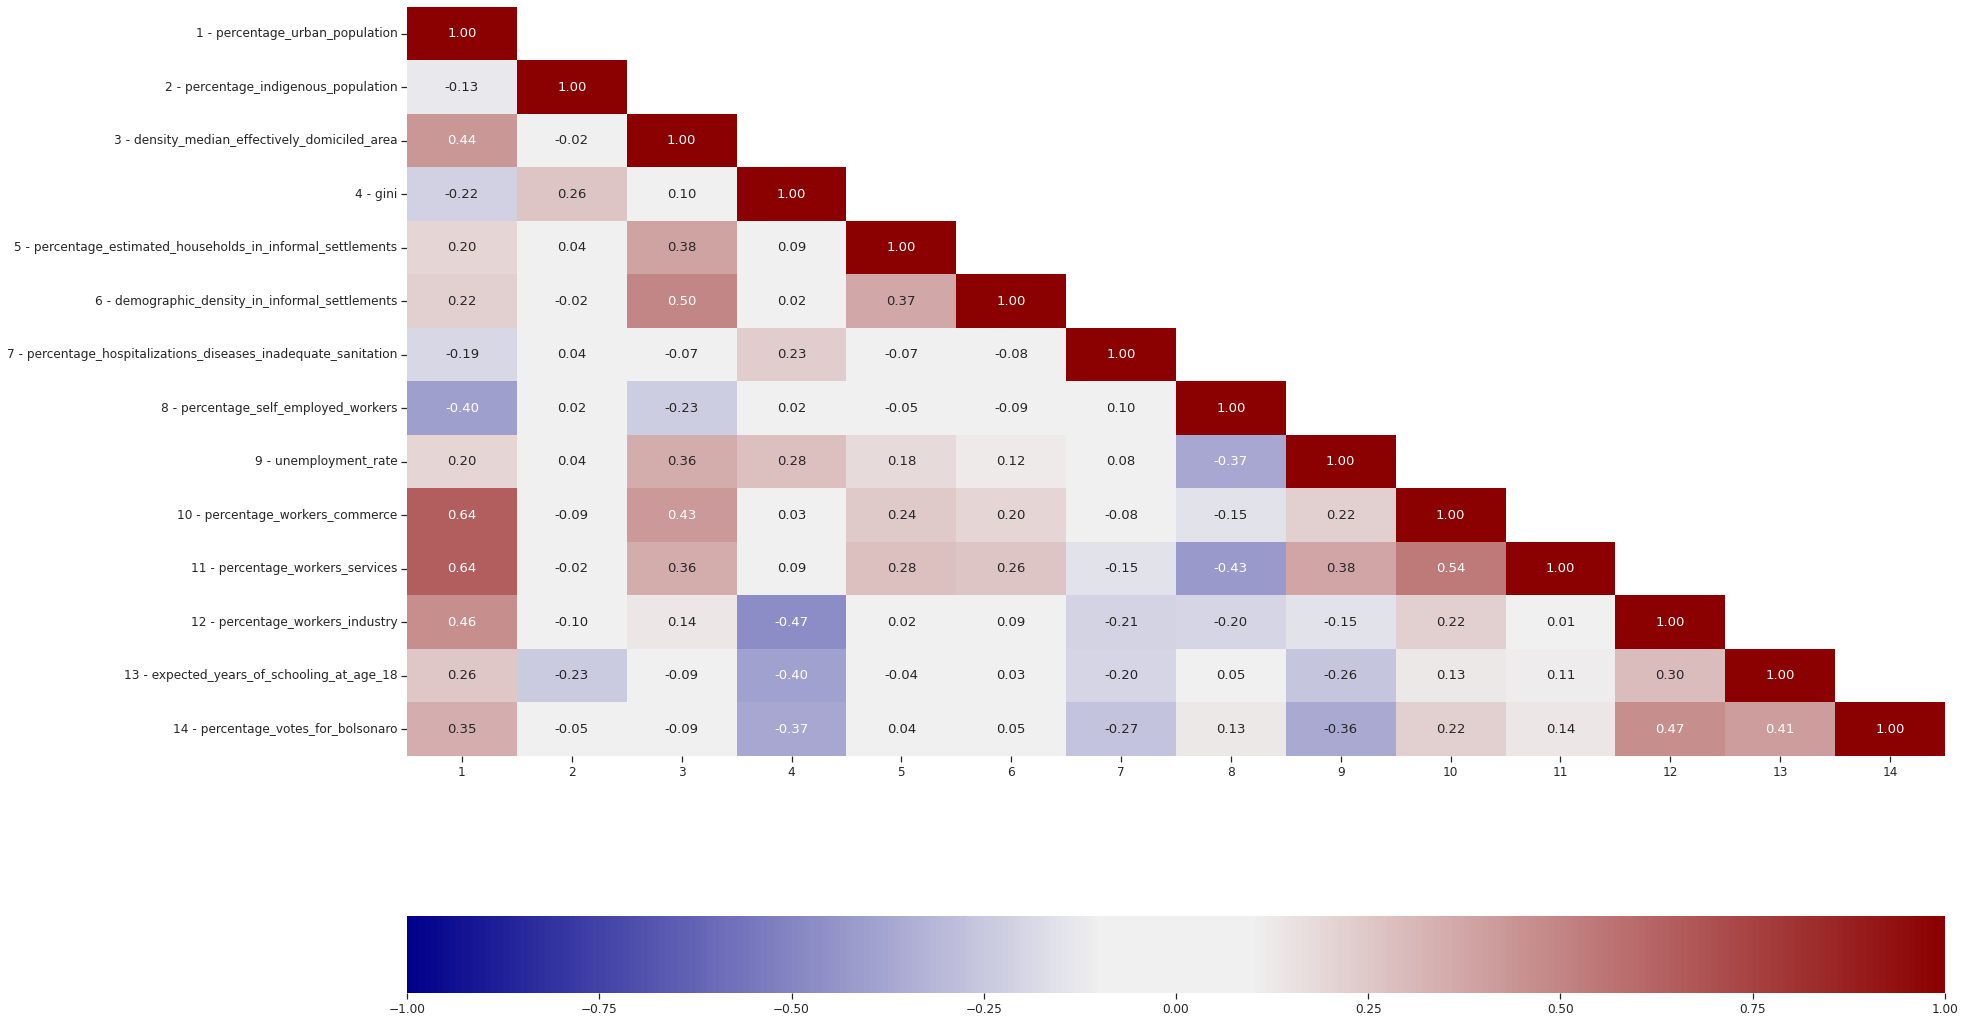

Selected alpha: 0.22
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2021   No. Observations:                 5515
Model:                              GLM   Df Residuals:                     5500
Model Family:          NegativeBinomial   Df Model:                           14
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -73307.
Date:                  Fri, 20 Jun 2025   Deviance:                       5835.8
Time:                          17:04:10   Pearson chi2:                 5.50e+03
No. Iterations:                       7   Pseudo R-squ. (CS):             0.3825
Covariance Type:              nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

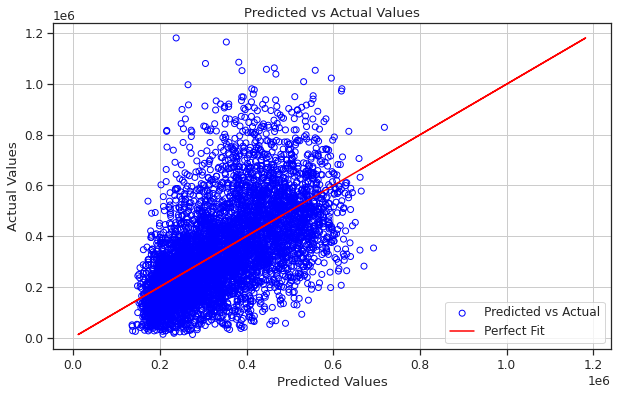

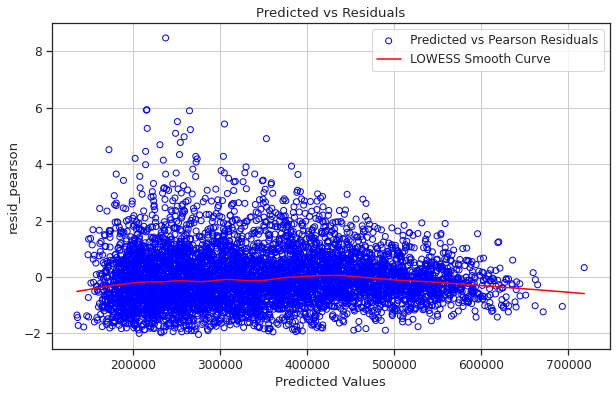


***Data:  resid_pearson
Shapiro-Wilk Test Statistic: 0.9424231052398682
p-value: 5.989149636524268e-42
Sample does not look Gaussian (reject H0)
Skewness: 1.1783913663142038
Kurtosis: 3.424304723037168


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


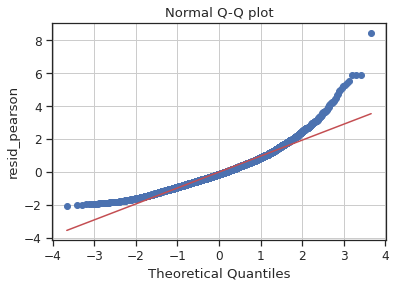


***Data:  y
Shapiro-Wilk Test Statistic: 0.9612597823143005
p-value: 4.995820140007731e-36
Sample does not look Gaussian (reject H0)
Skewness: 0.763486524446981
Kurtosis: 0.4563947871823344


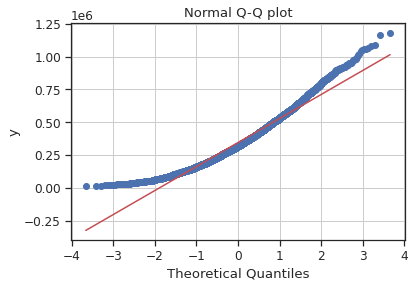

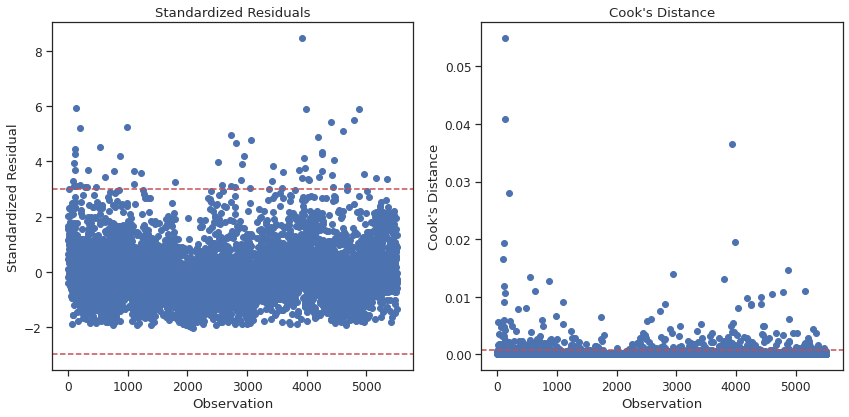

Quantity outliers (Standardized Residuals > 3): 63
Quantity influential Points (Cook's Distance > 4/n): 312

*** Period:  2022
Death mean:  58296.02 variance:  2491200245.18 dispersion:  42733.63


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


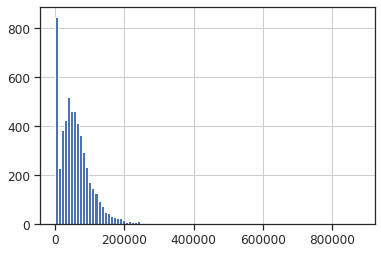

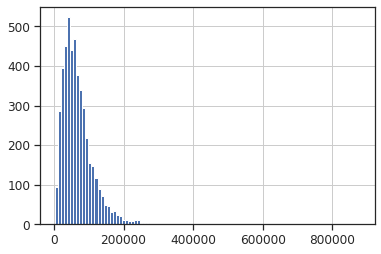


===> model_11_2022
                                              Feature       VIF
0                         percentage_urban_population  3.560787
1                    percentage_indigenous_population  1.130823
2           density_median_effectively_domiciled_area  1.975299
3                                                gini  1.646860
4   percentage_estimated_households_in_informal_se...  1.294677
5         demographic_density_in_informal_settlements  1.453317
6   percentage_hospitalizations_diseases_inadequat...  1.148422
7                    percentage_self_employed_workers  1.646229
8                                   unemployment_rate  1.666865
9                         percentage_workers_commerce  2.045059
10                        percentage_workers_services  2.771049
11                        percentage_workers_industry  2.096042
12              expected_years_of_schooling_at_age_18  1.437048
13                     percentage_votes_for_bolsonaro  1.972270


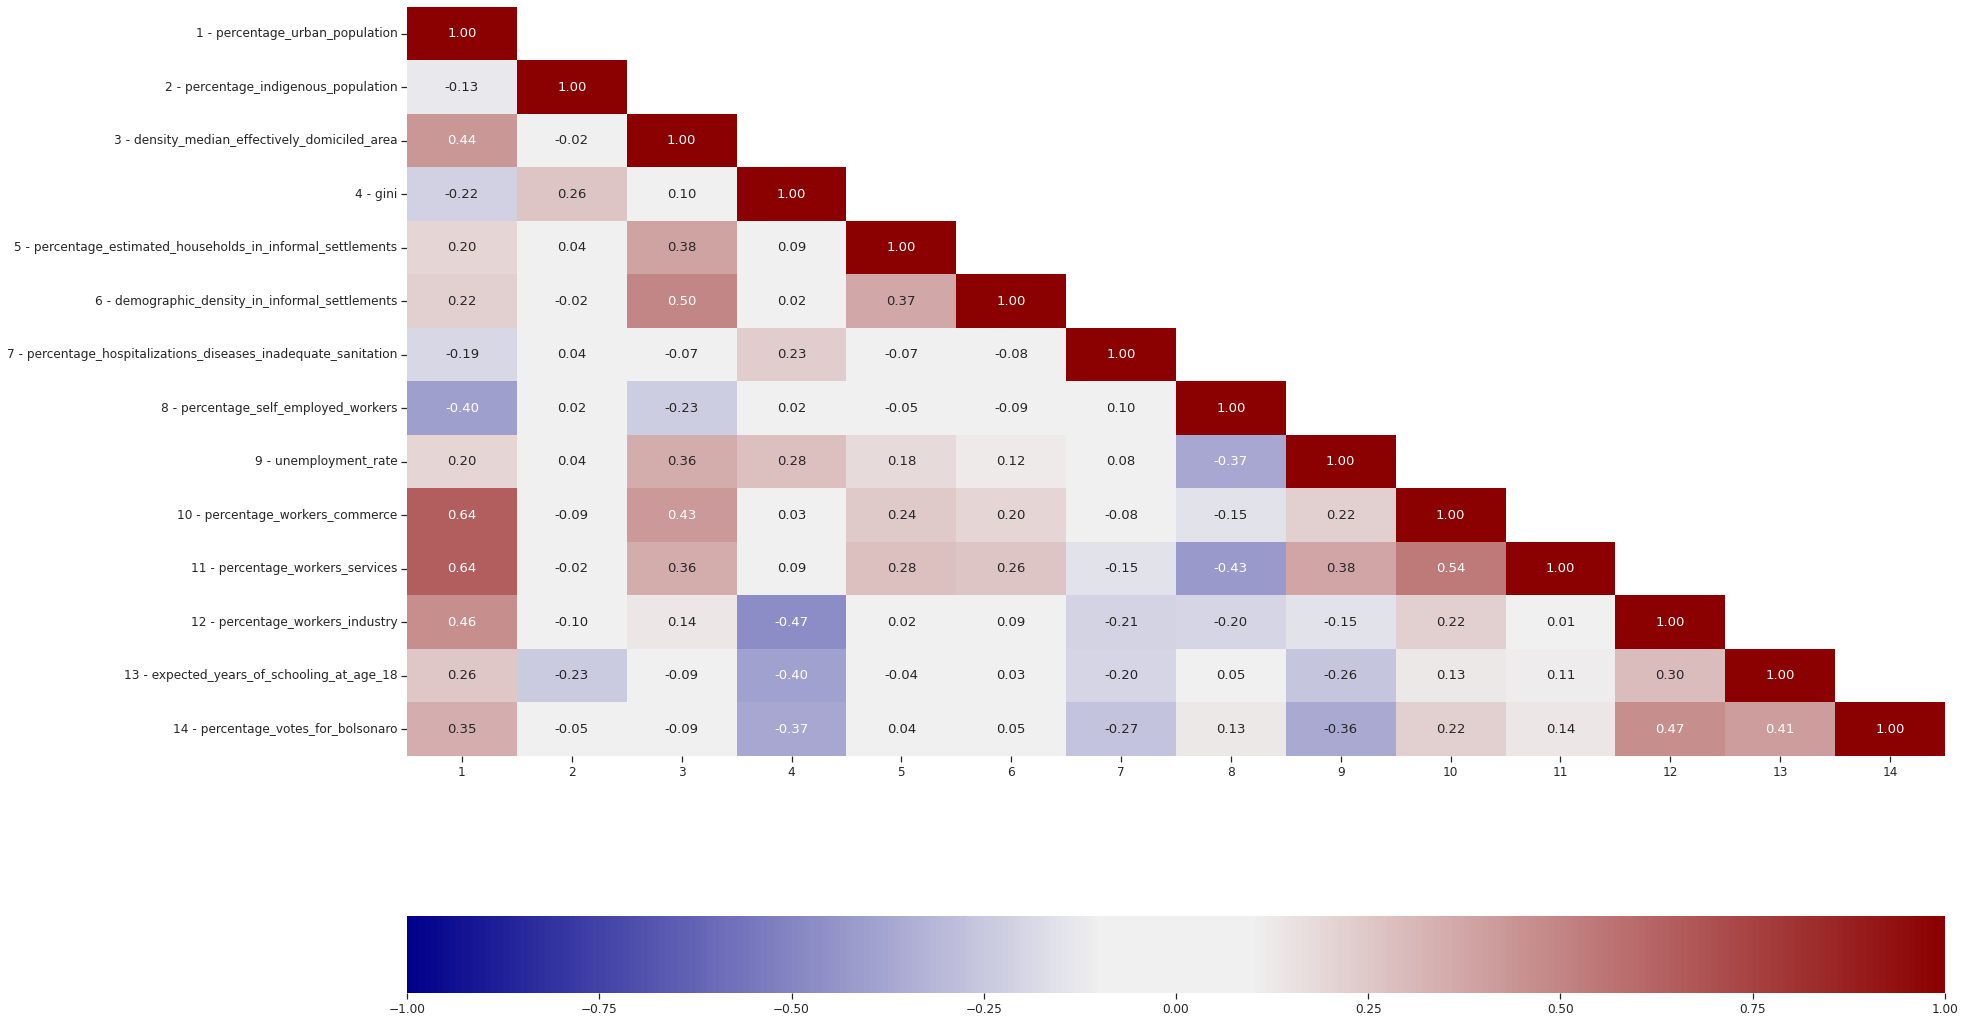

Selected alpha: 0.33
                  Generalized Linear Model Regression Results                   
Dep. Variable:     expected_deaths_2022   No. Observations:                 4751
Model:                              GLM   Df Residuals:                     4736
Model Family:          NegativeBinomial   Df Model:                           14
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -56249.
Date:                  Fri, 20 Jun 2025   Deviance:                       5002.0
Time:                          17:04:27   Pearson chi2:                 5.47e+03
No. Iterations:                       7   Pseudo R-squ. (CS):             0.1957
Covariance Type:              nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

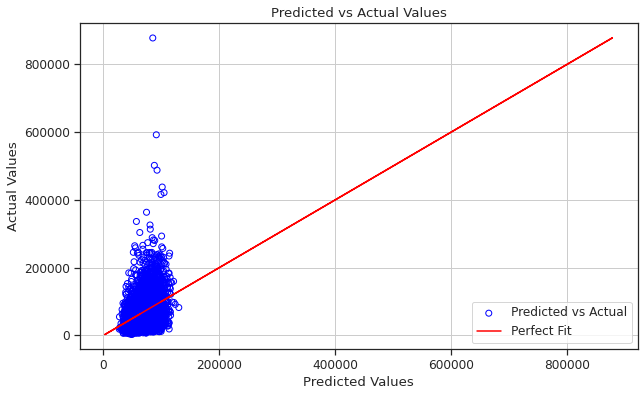

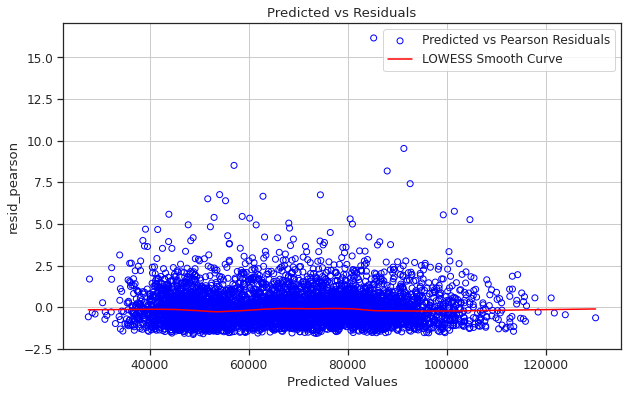


***Data:  resid_pearson
Shapiro-Wilk Test Statistic: 0.8556888103485107
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 2.449932504432595
Kurtosis: 17.32890971910962


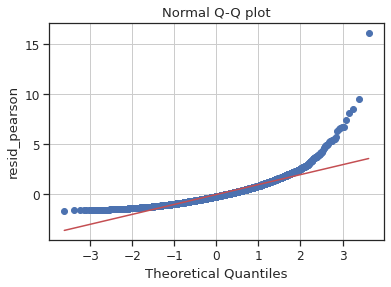


***Data:  y
Shapiro-Wilk Test Statistic: 0.8177109360694885
p-value: 0.0
Sample does not look Gaussian (reject H0)
Skewness: 3.080006635696479
Kurtosis: 27.714826161195916


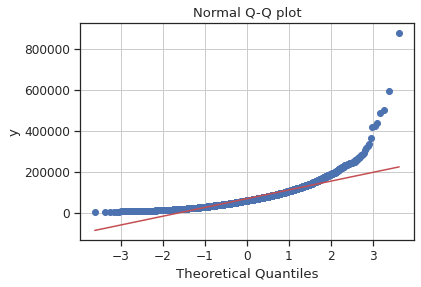

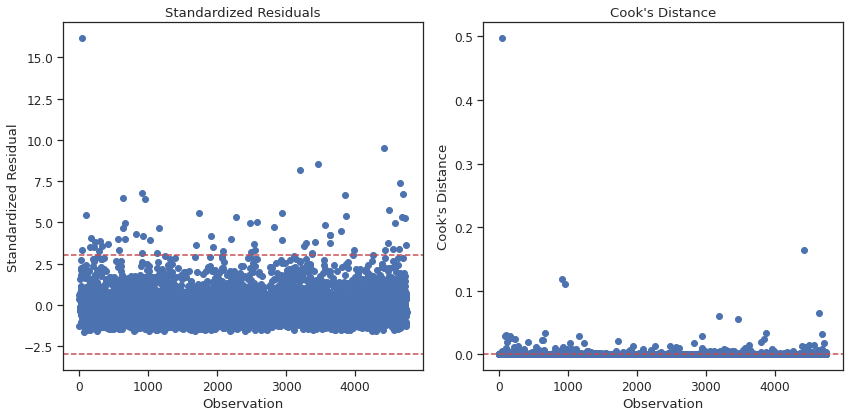

Quantity outliers (Standardized Residuals > 3): 69
Quantity influential Points (Cook's Distance > 4/n): 360

*** Period:  2020_2022
Death mean:  533594.66 variance:  64992145900.32 dispersion:  121800.59


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


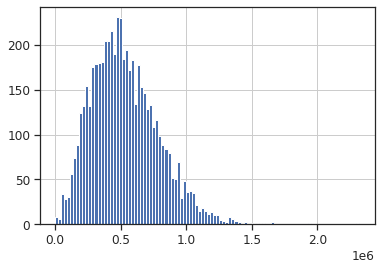

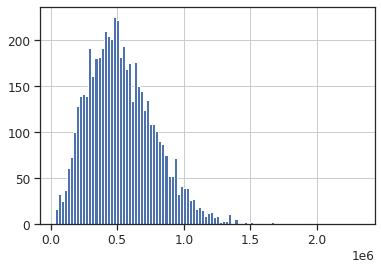


===> model_11_2020_2022
                                              Feature       VIF
0                         percentage_urban_population  3.560787
1                    percentage_indigenous_population  1.130823
2           density_median_effectively_domiciled_area  1.975299
3                                                gini  1.646860
4   percentage_estimated_households_in_informal_se...  1.294677
5         demographic_density_in_informal_settlements  1.453317
6   percentage_hospitalizations_diseases_inadequat...  1.148422
7                    percentage_self_employed_workers  1.646229
8                                   unemployment_rate  1.666865
9                         percentage_workers_commerce  2.045059
10                        percentage_workers_services  2.771049
11                        percentage_workers_industry  2.096042
12              expected_years_of_schooling_at_age_18  1.437048
13                     percentage_votes_for_bolsonaro  1.972270


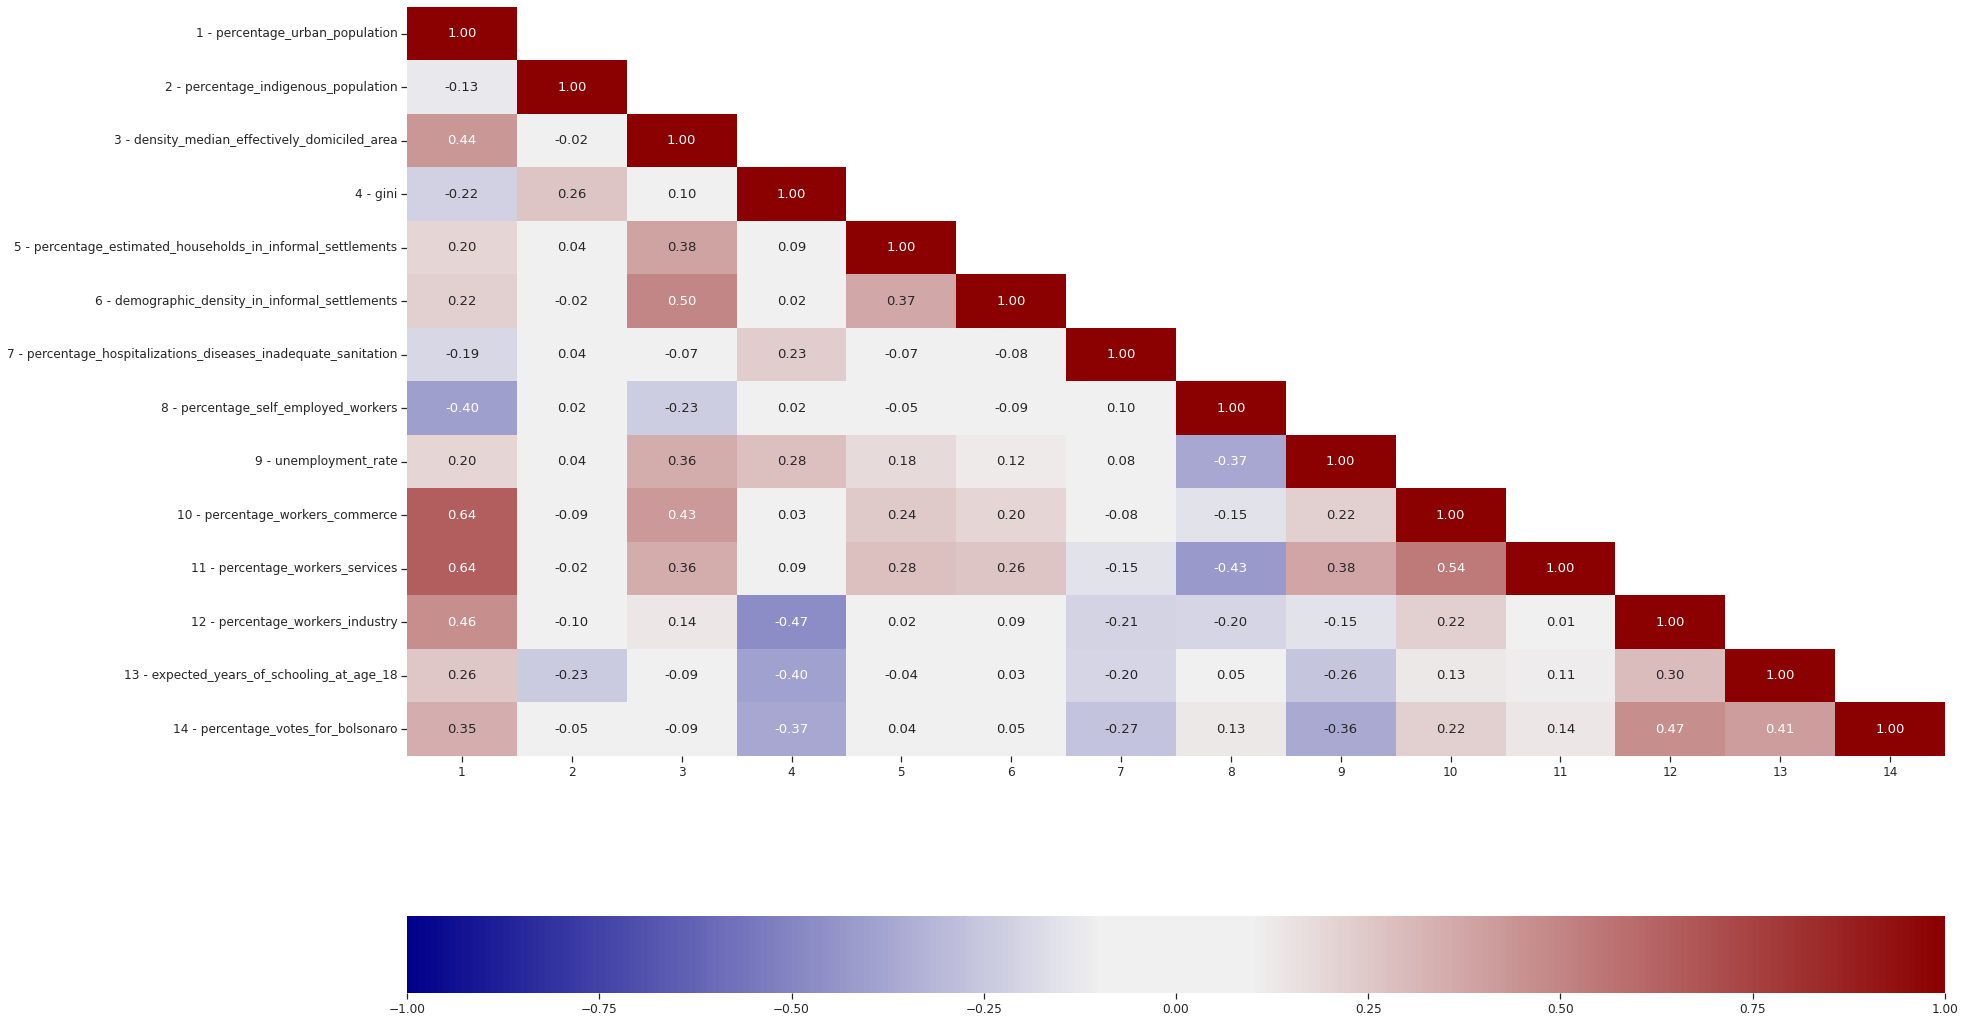

Selected alpha: 0.17
                   Generalized Linear Model Regression Results                    
Dep. Variable:     expected_deaths_entire   No. Observations:                 5552
Model:                                GLM   Df Residuals:                     5537
Model Family:            NegativeBinomial   Df Model:                           14
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -75543.
Date:                    Fri, 20 Jun 2025   Deviance:                       5550.4
Time:                            17:04:40   Pearson chi2:                 5.23e+03
No. Iterations:                         7   Pseudo R-squ. (CS):             0.4066
Covariance Type:                nonrobust                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------

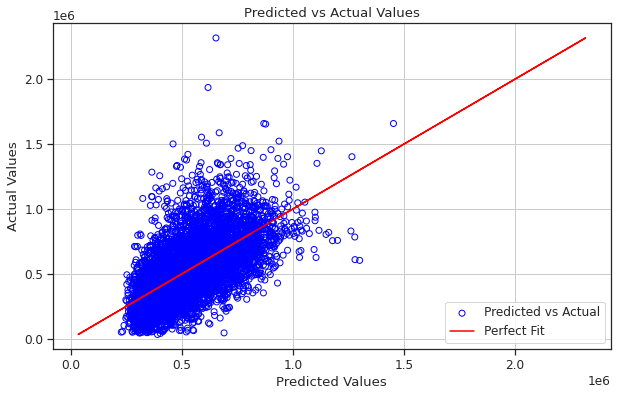

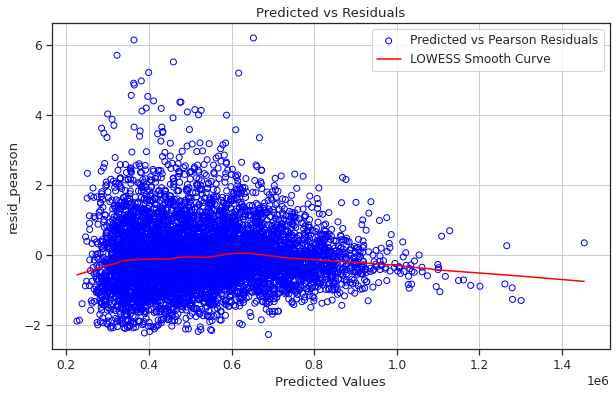


***Data:  resid_pearson
Shapiro-Wilk Test Statistic: 0.9583537578582764
p-value: 3.5640631867870026e-37
Sample does not look Gaussian (reject H0)
Skewness: 0.9660366776028765
Kurtosis: 2.493524733823464


/home/helder/anaconda3/envs/base-r/lib/python3.9/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


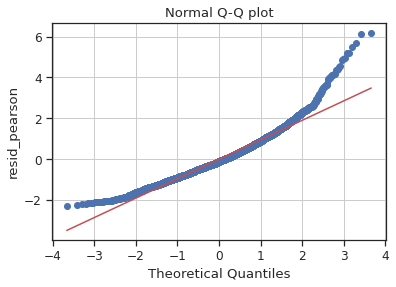


***Data:  y
Shapiro-Wilk Test Statistic: 0.97057044506073
p-value: 2.740630401858814e-32
Sample does not look Gaussian (reject H0)
Skewness: 0.7233584465479489
Kurtosis: 0.9350246580105939


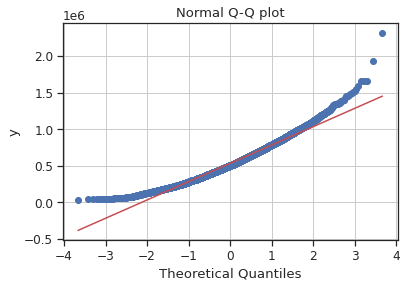

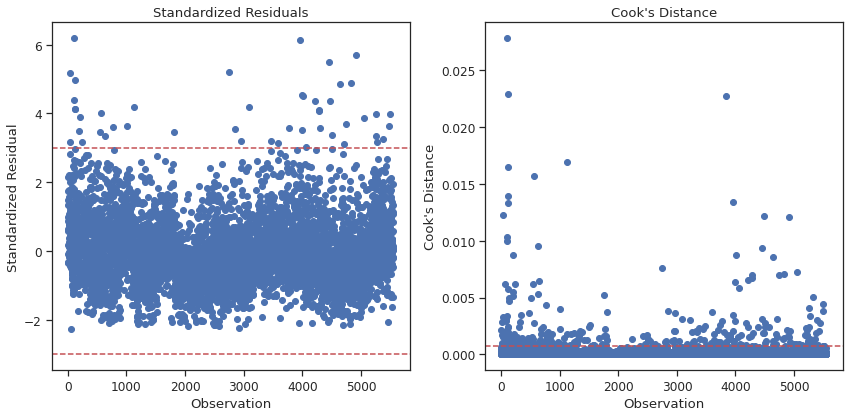

Quantity outliers (Standardized Residuals > 3): 48
Quantity influential Points (Cook's Distance > 4/n): 305


In [40]:
list_periods = ['2020_1','2020', '2021', '2022', '2020_2022']
list_columns_y = ['expected_deaths_1s_2020', 'expected_deaths_2020', 'expected_deaths_2021', 'expected_deaths_2022', 'expected_deaths_entire']
# list_columns_y = ['deaths_accumulated_first_semester_2020', 'deaths_accumulated_2020', 'deaths_2021', 'deaths_2022']
list_delta_first_death_columns = ['delta_first_death_2020-06-30', 'delta_first_death_2020-12-31', 'delta_first_death_2021-12-31', 'delta_first_death_2022-12-31', 'delta_first_death_general_period']

for i in range(5):
    period = list_periods[i]
    weights = None
    print('\n*** Period: ', period)

    column_y = list_columns_y[i]
    y = df_y[column_y]
    column_delta_first_death = list_delta_first_death_columns[i]
    list_offset_extra = np.log(df_y[column_delta_first_death]+1)
    list_offset_latitude = np.log(df_latitude_longitude['latitude'])
    list_offset_longitude = np.log(df_latitude_longitude['longitude'])

    print('Death mean: ', round(y.mean(),2), 'variance: ', round(y.var(),2), 'dispersion: ', round(y.var()/y.mean(),2))
    # # Model 0
    # x = df_regions.copy()
    # x = pd.get_dummies(x, columns=['region'], drop_first=True, dtype=int)
    # x = x.sort_index()
    # run_model(x, y, 'model_0', period, is_offset_default=False)

    # # # Model 1
    # x = df_regions.copy()
    # x = pd.get_dummies(x, columns=['region'], drop_first=True, dtype=int)
    # x = x.sort_index()
    # if period != '2020_2022':
    #     model1 = run_model(x, y, 'model_1', period, list_offset_extra=list_offset_extra)
    # else:
    #     x = pd.concat([x,x,x], ignore_index=True)
    #     model1 = run_model(x, y, 'model_1', period, list_offset_extra=list_offset_extra, weights=weights)

    # # # Model 2
    # x = df_cluster_labels.copy()
    # x = pd.get_dummies(x, columns=['cluster_label'], drop_first=True, dtype=int)
    # x = x.sort_index()
    # run_model(x, y, 'model_2', period, is_offset_default=False)

    # # Model 3
    # x = df_cluster_labels.copy()
    # x = pd.get_dummies(x, columns=['cluster_label'], drop_first=True, dtype=int)
    # x = x.sort_index()
    # run_model(x, y, 'model_3', period, list_offset_extra=list_offset_extra, is_offset_default=False)

    # Model 4
    # x = df_latitude_longitude.copy()
    # x = x.sort_index()
    # run_model(x, y, 'model_4', period)

    # Model 5
    # x = df_cluster_labels.copy()
    # x = pd.get_dummies(x, columns=['cluster_label'], drop_first=True, dtype=int)
    # x = x.sort_index()
    # df_latitude_longitude = df_latitude_longitude.sort_index()
    # x = pd.concat([df_latitude_longitude, x], axis=1)
    # run_model(x, y, 'model_5', period)

    # Model 6
    # x = df_cluster_probabilities.drop(columns=['Urbanized']).copy()
    # run_model(x, y, 'model_6', period, is_offset_default=False)

    # Model 7
    # x = df_cluster_probabilities.drop(columns=['Urbanized']).copy()
    # x = pd.concat([df_latitude_longitude, x], axis=1)
    # scaler = StandardScaler()
    # x_standardized = scaler.fit_transform(x)
    # x = pd.DataFrame(x_standardized, index=x.index, columns=x.columns)
    # run_model(x, y, 'model_7', period)

    # Model 8
    # x = df_cluster_probabilities.drop(columns=['Urbanized']).copy()
    # x = pd.concat([df_latitude_longitude, x], axis=1)
    # scaler = StandardScaler()
    # x_standardized = scaler.fit_transform(x)
    # x = pd.DataFrame(x_standardized, index=x.index, columns=x.columns)
    # run_model(x, y, 'model_8', period, list_offset_extra=list_offset_extra)

    # # Model 9
    # x = df_cluster_probabilities.drop(columns=['Urbanized']).copy()
    # run_model(x, y, 'model_9', period, list_offset_extra=list_offset_extra, is_offset_default=False)

    # Model 10
    # x = df_variables.copy()
    # scaler = StandardScaler()
    # percentage_votes_for_bolsonaro_standardized = scaler.fit_transform(df_political)
    # x['percentage_votes_for_bolsonaro'] = percentage_votes_for_bolsonaro_standardized[:,0]
    # x = x.loc[x.index.isin(y.index)]
    # y.hist(bins=100)
    # plt.show()
    # y[y>0].hist(bins=100)
    # plt.show()
    # run_model(x, y, 'model_10', period, list_offset_extra=list_offset_extra, is_offset_default=False)

    # x_infl = pd.DataFrame()
    # x_infl['population'] = df_y.loc[df_y.index.isin(y.index), 'population']
    # x_infl['delta_first_death'] = df_y.loc[df_y.index.isin(y.index), column_delta_first_death]
    # temp_scaled = scaler.fit_transform(x_infl)
    # x_infl['population'] = temp_scaled[:,0]
    # x_infl['delta_first_death'] = temp_scaled[:,1]
    # x_infl = sm.add_constant(x_infl)
    # x_infl.index = x.index
    #
    # run_model(x, y, 'model_10', period, list_offset_extra=list_offset_extra, is_offset_default=False, x_infl=x_infl)

    # Model 11
    x = df_variables.copy()
    scaler = StandardScaler()
    percentage_votes_for_bolsonaro_standardized = scaler.fit_transform(df_political)
    x['percentage_votes_for_bolsonaro'] = percentage_votes_for_bolsonaro_standardized[:,0]
    x = x.loc[x.index.isin(y.index)]
    y.hist(bins=100)
    plt.show()
    y[y>0].hist(bins=100)
    plt.show()
    run_model(x, y, 'model_11', period, is_offset_default=False)

In [26]:
x

,percentage_urban_population,percentage_indigenous_population,density_median_effectively_domiciled_area,gini,percentage_estimated_households_in_informal_settlements,demographic_density_in_informal_settlements,percentage_hospitalizations_diseases_inadequate_sanitation,percentage_self_employed_workers,unemployment_rate,percentage_workers_commerce,percentage_workers_services,percentage_workers_industry,expected_years_of_schooling_at_age_18,percentage_votes_for_bolsonaro
0,-0.296800,0.371415,-0.596432,1.296166,-0.231671,-0.174949,0.318363,1.019514,-0.176079,0.728350,0.081283,-0.711839,-0.722666,1.579097
1,0.947781,-0.179301,0.263102,0.539257,-0.163265,-0.174949,-0.200168,0.301861,-0.427022,1.683908,0.855398,-0.056770,-0.258143,2.038128
2,-0.960097,-0.165356,-0.643147,0.236493,-0.231671,-0.174949,0.927261,0.841877,-1.004713,-0.933097,0.500970,-0.631077,0.570712,1.415240
3,0.680480,0.120440,-0.090811,1.144784,0.191127,-0.174949,-0.238896,0.028808,-0.121185,1.913151,0.744006,0.092415,0.251921,1.804006
4,0.946765,-0.172215,-0.452527,0.085111,-0.231671,-0.174949,0.709951,0.383066,-0.267568,0.796442,0.667495,-0.306908,0.689119,2.110113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,0.420578,-0.172920,-0.212128,-0.520416,-0.231671,-0.174949,1.103690,0.178023,-0.709332,0.562659,0.713627,0.460330,0.588928,1.076259
5566,0.995862,-0.149365,-0.009378,-0.520416,-0.231671,-0.174949,-0.230290,-0.738583,-0.134255,0.022462,0.230930,0.749727,0.552495,0.443340
5567,0.460540,-0.164881,-0.185596,-0.217652,-0.231671,-0.174949,0.167753,-1.115173,0.571522,-0.731090,-0.160628,0.588203,0.935043,-0.533896
5568,-1.569425,-0.181779,-0.603939,-0.369034,0.273356,-0.174949,-0.438993,-0.111271,-0.596931,-1.225893,-0.393538,-0.295691,-0.003111,0.441521


In [27]:
df_y

,code_municipality_6,code_municipality_7,population,date,region,deaths,new_deaths,deaths_accumulated_first_semester_2020,delta_first_death_2020-06-30,deaths_accumulated_2020,...,expected_deaths_entire,SMR_1s_2020,expected_deaths_1s_2020,SMR_2020,expected_deaths_2020,SMR_2021,expected_deaths_2021,SMR_2022,expected_deaths_2022,inverse_death_weighted_SMR
0,110001,1100015,21495,2022-12-31,North,93.0,0.0,0.0,0.0,16.0,...,927589.0,0.0,0.0,0.0,165302.0,0.0,662963.0,0.0,99324.0,0.0
1,110002,1100023,96833,2022-12-31,North,540.0,0.0,20.0,44.0,122.0,...,1457150.0,0.0,50555.0,0.0,326190.0,0.0,1023756.0,0.0,107204.0,0.0
2,110003,1100031,5363,2022-12-31,North,15.0,0.0,1.0,0.0,4.0,...,480554.0,0.0,26687.0,0.0,146119.0,0.0,309690.0,0.0,24745.0,0.0
3,110004,1100049,86895,2022-12-31,North,351.0,0.0,6.0,85.0,60.0,...,930313.0,0.0,15814.0,0.0,158365.0,0.0,698194.0,0.0,73754.0,0.0
4,110005,1100056,15890,2022-12-31,North,76.0,0.0,2.0,41.0,8.0,...,1042295.0,0.0,24714.0,0.0,115823.0,0.0,778723.0,0.0,147748.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,522200,5222005,14956,2022-12-31,Midwestern,47.0,0.0,0.0,0.0,7.0,...,651089.0,0.0,0.0,0.0,95000.0,0.0,441110.0,0.0,114980.0,0.0
5566,522205,5222054,8768,2022-12-31,Midwestern,34.0,0.0,1.0,20.0,8.0,...,973173.0,0.0,30700.0,0.0,249990.0,0.0,700742.0,0.0,22442.0,0.0
5567,522220,5222203,4215,2022-12-31,Midwestern,7.0,0.0,0.0,0.0,2.0,...,653860.0,0.0,0.0,0.0,195094.0,0.0,237233.0,0.0,221534.0,0.0
5568,522230,5222302,5815,2022-12-31,Midwestern,11.0,0.0,1.0,2.0,3.0,...,390316.0,0.0,43977.0,0.0,117888.0,0.0,246924.0,0.0,25504.0,0.0


In [28]:
x.describe().round(2)

,percentage_urban_population,percentage_indigenous_population,density_median_effectively_domiciled_area,gini,percentage_estimated_households_in_informal_settlements,demographic_density_in_informal_settlements,percentage_hospitalizations_diseases_inadequate_sanitation,percentage_self_employed_workers,unemployment_rate,percentage_workers_commerce,percentage_workers_services,percentage_workers_industry,expected_years_of_schooling_at_age_18,percentage_votes_for_bolsonaro
count,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00,5560.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.71,-0.20,-1.37,-3.25,-0.23,-0.17,-0.68,-2.37,-1.76,-2.23,-2.70,-1.08,-4.67,-1.94
25%,-0.76,-0.19,-0.63,-0.67,-0.23,-0.17,-0.55,-0.67,-0.68,-0.75,-0.71,-0.71,-0.65,-0.91
50%,0.04,-0.18,-0.21,-0.07,-0.23,-0.17,-0.36,-0.21,-0.12,-0.12,-0.06,-0.35,0.01,0.09
75%,0.83,-0.16,0.36,0.69,-0.23,-0.17,0.12,0.41,0.49,0.65,0.62,0.41,0.68,0.80
max,1.64,15.53,11.05,4.63,16.17,17.08,11.81,5.28,9.20,5.90,5.15,6.23,3.07,2.64
